### Overview
In this notebook, we evaluate traditional, widely used machine learning paradigms for supervised learning on tabular data. 
Before exploring complex deep learning architectures, it is essential to establish strong, interpretable baselines. 

We will systematically evaluate each model across two distinct domains simultaneously:
* **Standard Tabular Data:** A classic dataset containing a mix of informative and noise features, typical of finance or standard clinical records.
* **Biological Data ($P \gg N$):** A high-dimensional oncology dataset characterized by having significantly more features (genes) than samples (patients). This domain is highly susceptible to the "Curse of Dimensionality" and extreme overfitting.

**Terminology:**
* **$N$ (Number of Samples):** The number of data points in the dataset. 
* **$P$ (Number of Features):** The number of dimensions for each sample. In our datasets, while some dimensions contain the true informative signal, there are also additional nuisance dimensions (noise). These nuisance dimensions are irrelevant to the underlying structure of the data and serve to challenge the feature selection and classification algorithms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# 1. Standard Tabular Data (N=1000, P=20)
X_std, y_std = make_classification(n_samples=1000, n_features=20, n_informative=5, random_state=42)
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y_std,test_size=0.3, random_state=42 )

# 2. High-Dimensional Biological Data (N=500, P=2000)
X_bio, y_bio = make_classification(n_samples=500, n_features=2000,n_informative=10, random_state=42)
X_train_bio, X_test_bio, y_train_bio, y_test_bio = train_test_split(X_bio, y_bio,test_size=0.3,random_state=42 )

print(f"Standard Data - Train: {X_train_std.shape}, Test: {X_test_std.shape}")
print(f"Biological Data - Train: {X_train_bio.shape}, Test: {X_test_bio.shape}")


Standard Data - Train: (700, 20), Test: (300, 20)
Biological Data - Train: (350, 2000), Test: (150, 2000)


### Linear Baselines: Standard Logistic Regression vs. LASSO

We begin with linear models. Standard Logistic Regression provides a highly interpretable baseline, but it lacks built-in feature selection. To counter this, we introduce **LASSO (L1 Regularization)**, which forces the weights of irrelevant features to exactly zero.

Let's observe how these two models perform across both datasets. We expect them to perform similarly on the standard data, but predict a catastrophic failure for the unregularized model on the high-dimensional biological data.

In [2]:
def train_and_eval(model, X_tr, y_tr, X_te, y_te): # tr = train, te = test
    model.fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))

# Models 
lr = LogisticRegression(penalty=None, max_iter=500)
lasso = LogisticRegression(penalty='l1',solver='saga', max_iter=500)
print("--- Standard Data (P=20) ---")
print(f"Stadard Logistic Regression Accuracy: {train_and_eval(lr, X_train_std, y_train_std, X_test_std, y_test_std)}")
print(f"LASSO (L1) Accuracy: {train_and_eval(lasso, X_train_std, y_train_std, X_test_std, y_test_std)}")

print("\n")
print("--- Biological Data (P=2000) ---")
print(f"Stadard Logistic Regression Accuracy: {train_and_eval(lr, X_train_bio, y_train_bio, X_test_bio, y_test_bio)}")
print(f"LASSO (L1) Accuracy: {train_and_eval(lasso, X_train_bio, y_train_bio, X_test_bio, y_test_bio)}")

lasso.fit(X_train_bio, y_train_bio)
retained = np.sum(lasso.coef_ != 0)
print(f"\n* Note: On the biological data, LASSO retained only {retained} out of 2000 features.")

--- Standard Data (P=20) ---
Stadard Logistic Regression Accuracy: 0.8066666666666666
LASSO (L1) Accuracy: 0.8033333333333333


--- Biological Data (P=2000) ---
Stadard Logistic Regression Accuracy: 0.6866666666666666
LASSO (L1) Accuracy: 0.7466666666666667

* Note: On the biological data, LASSO retained only 323 out of 2000 features.


### Gradient Boosted Decision Trees (XGBoost)

XGBoost represents the state-of-the-art for traditional tabular data. It handles non-linearities and unnormalized data natively. 

However, tree-based models can struggle when the signal-to-noise ratio is extremely low (as seen in our biological dataset with 1,990 noise features). Let's evaluate its robustness across both domains.

In [4]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=45)

print("--- XGBoost Performance ---")
xgb_std_acc = train_and_eval(xgb_model, X_train_std, y_train_std, X_test_std, y_test_std)
xgb_bio_acc = train_and_eval(xgb_model, X_train_bio, y_train_bio, X_test_bio, y_test_bio)

print(f"Accuracy on Standard Data: {xgb_std_acc:.3f}")
print(f"Accuracy on Biological Data: {xgb_bio_acc:.3f}")

--- XGBoost Performance ---
Accuracy on Standard Data: 0.947
Accuracy on Biological Data: 0.787


### Systematic Comparison

Visualizing the results side-by-side reveals the true nature of tabular machine learning:
* **The Standard Domain:** XGBoost demonstrates its dominance, efficiently capturing the underlying patterns.
* **The High-Dimensional Domain:** Extreme dimensionality cripples standard linear models, and even XGBoost struggles with the overwhelming noise. Here, the aggressive feature selection of LASSO proves to be the most resilient strategy.

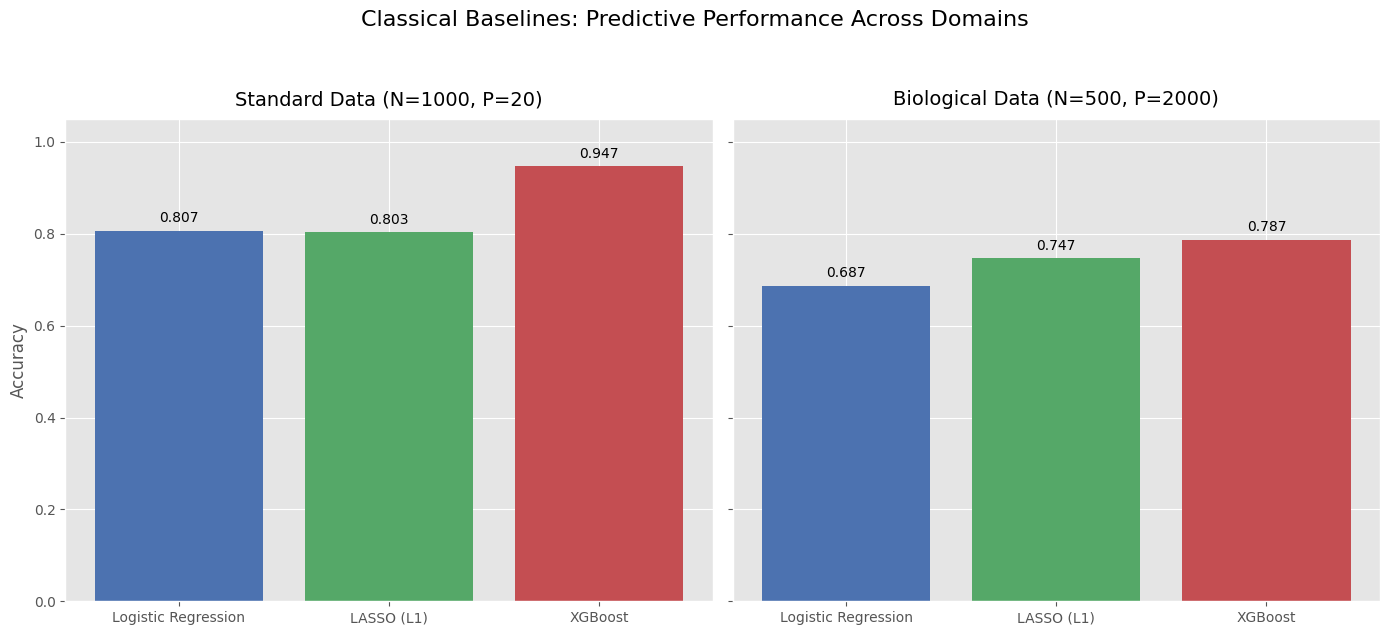

In [9]:
# Gather all results
results = {
    'Logistic Regression': [
        train_and_eval(lr, X_train_std, y_train_std, X_test_std, y_test_std),
        train_and_eval(lr, X_train_bio, y_train_bio, X_test_bio, y_test_bio)
    ],
    'LASSO (L1)':[
        train_and_eval(lasso, X_train_std, y_train_std, X_test_std, y_test_std), 
        train_and_eval(lasso, X_train_bio, y_train_bio, X_test_bio, y_test_bio)          
    ],
    'XGBoost': [xgb_std_acc, xgb_bio_acc]
}

# Setup the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), sharey=True)
models = list(results.keys())

# Standard Data Plot
ax1.bar(models,[res[0] for res in results.values()],color=['#4C72B0', '#55A868', '#C44E52'])
ax1.set_title('Standard Data (N=1000, P=20)', fontsize=14, pad=10)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1.05)

# Biological Data Plot
ax2.bar(models, [res[1] for res in results.values()], color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('Biological Data (N=500, P=2000)', fontsize=14, pad=10)

# Add value labels
for ax in [ax1, ax2]:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')
        

plt.suptitle('Classical Baselines: Predictive Performance Across Domains', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()
